In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
def graficar(df_merged, nombre, color="steelblue"):
    NAME = nombre
    COLOR = color

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_vpd, ax_cmd = axes[0]
    ax_hist, ax_radial = axes[1]

    fig.suptitle(NAME, fontsize=13)

    # VPD
    ax_vpd.plot(df_merged['pmra'], df_merged['pmdec'],
                marker='o', linestyle='None', markersize=4,
                color=COLOR, alpha=0.7)
    ax_vpd.set_xlabel("pmra [mas $yr^{-1}$]")
    ax_vpd.set_ylabel("pmdec [mas $yr^{-1}$]")
    ax_vpd.set_title("VPD")

    # CMD
    ax_cmd.plot(df_merged['phot_bp_mean_mag'] - df_merged['phot_rp_mean_mag'],
                df_merged['phot_g_mean_mag'],
                marker='o', linestyle='None', markersize=4,
                color=COLOR, alpha=0.7)
    ax_cmd.set_xlabel("BP-RP")
    ax_cmd.set_ylabel("G")
    ax_cmd.invert_yaxis()
    ax_cmd.set_title("CMD")

    # Histograma de distancias
    d_median = df_merged['distance'].median()
    ax_hist.hist(df_merged['distance'], bins=30, color=COLOR, alpha=0.8)
    ax_hist.axvline(d_median, color='red', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {d_median:.1f} pc')
    ax_hist.set_xlabel("Distancia [pc]")
    ax_hist.set_ylabel("Número de estrellas")
    ax_hist.set_title("Distancias")
    ax_hist.legend(fontsize=9)

    # Perfil radial
    ra_c  = df_merged['ra'].median()
    dec_c = df_merged['dec'].median()
    d_c   = df_merged['distance'].median()

    delta_ra  = np.deg2rad(df_merged['ra']  - ra_c) * np.cos(np.deg2rad(dec_c))
    delta_dec = np.deg2rad(df_merged['dec'] - dec_c)
    r_pc = np.tan(np.sqrt(delta_ra**2 + delta_dec**2)) * d_c

    r_max = np.percentile(r_pc, 98)
    bins  = np.linspace(0, r_max, 15)
    counts, edges = np.histogram(r_pc, bins=bins)
    areas   = np.pi * (edges[1:]**2 - edges[:-1]**2)
    density = counts / areas
    r_mid   = 0.5 * (edges[:-1] + edges[1:])

    ax_radial.plot(r_mid, density, marker='o', color=COLOR, linewidth=1.5, markersize=4)
    ax_radial.set_xlabel("Radio [pc]")
    ax_radial.set_ylabel("Densidad [estrellas / pc²]")
    ax_radial.set_title("Perfil radial")

    plt.tight_layout()
    plt.show()

In [49]:
df100 = pd.read_csv("39_001_100pc.csv")
df130 = pd.read_csv("39_001_130pc.csv")
# Antes del merge, quédate solo con source_id en uno de los dos
df_merged = pd.merge(df100, df130[['source_id']], on='source_id')

In [50]:
df_merged.shape

(150, 32)

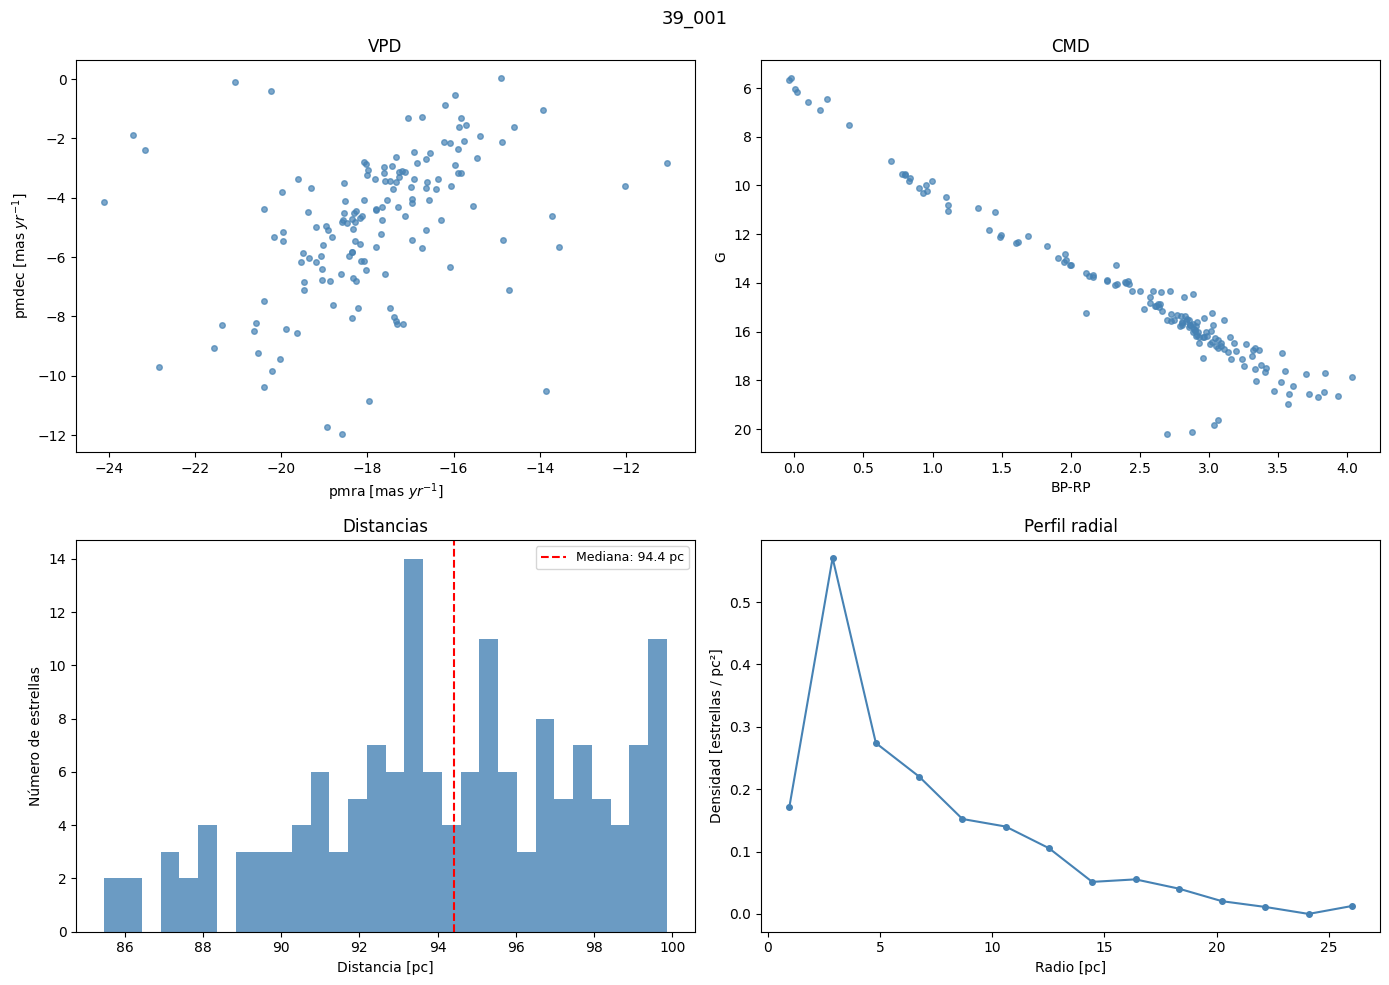

In [51]:
graficar(df_merged, "39_001")

In [52]:
df100 = pd.read_csv("63_001_100pc.csv")
df130 = pd.read_csv("63_001_130pc.csv")
# Antes del merge, quédate solo con source_id en uno de los dos
df_merged = pd.merge(df100, df130[['source_id']], on='source_id')
df_merged.shape

(77, 32)

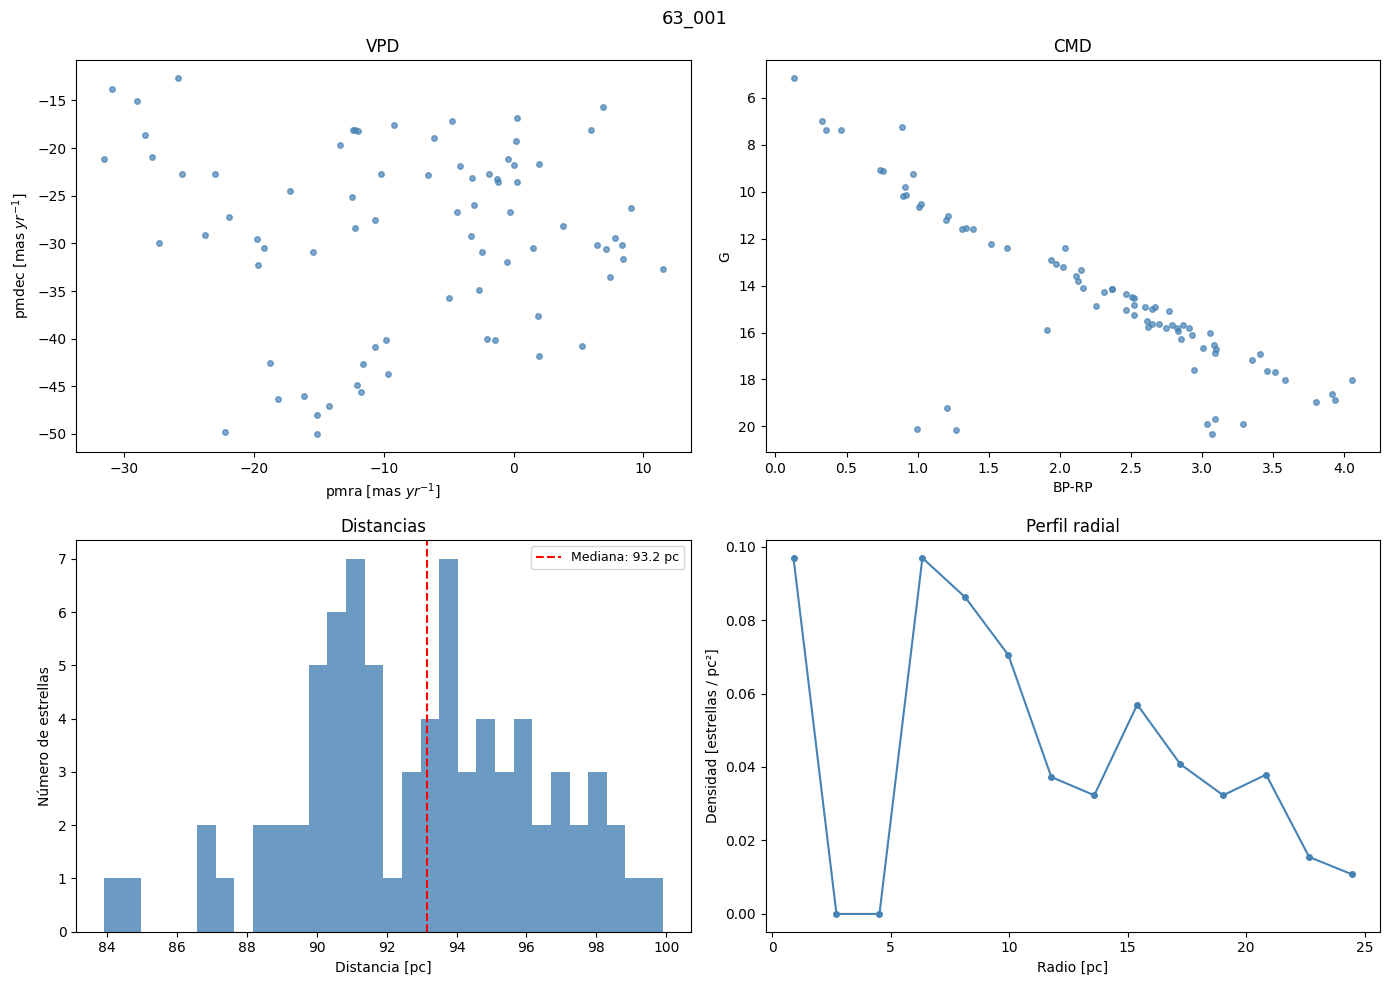

In [53]:
graficar(df_merged, "63_001")

In [54]:
df100 = pd.read_csv("38_000_100pc.csv")
df130 = pd.read_csv("38_001_130pc.csv")
# Antes del merge, quédate solo con source_id en uno de los dos
df_merged = pd.merge(df100, df130[['source_id']], on='source_id')
df_merged.shape

(273, 32)

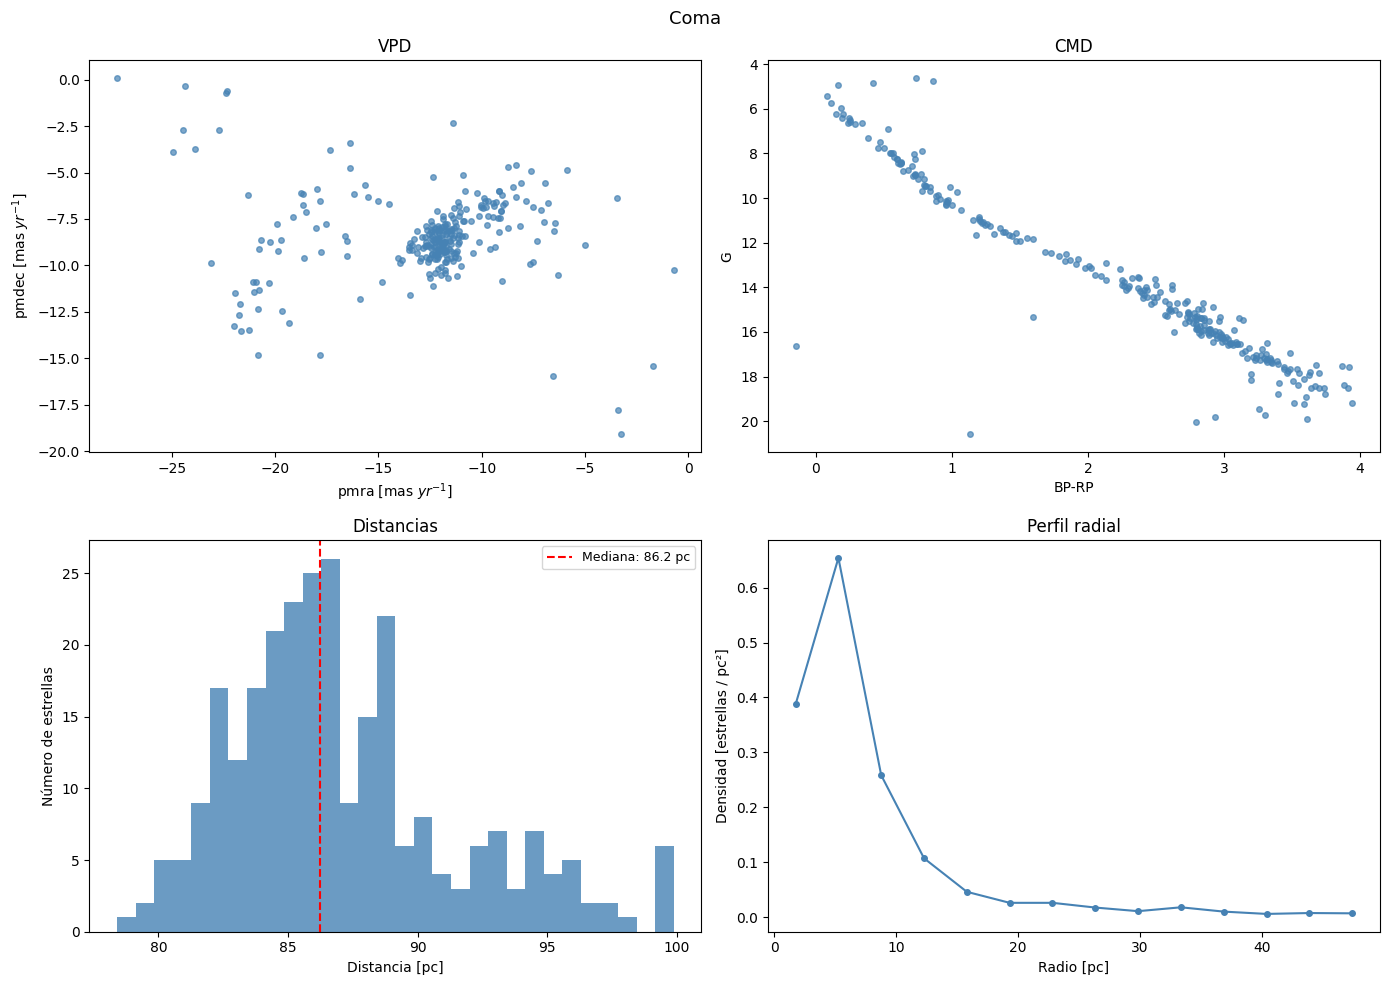

In [55]:
graficar(df_merged, "Coma")

In [56]:
df100 = pd.read_csv("13_001_100pc.csv")
df130 = pd.read_csv("13_001_130pc.csv")
# Antes del merge, quédate solo con source_id en uno de los dos
df_merged = pd.merge(df100, df130[['source_id']], on='source_id')
df_merged.shape

(344, 32)

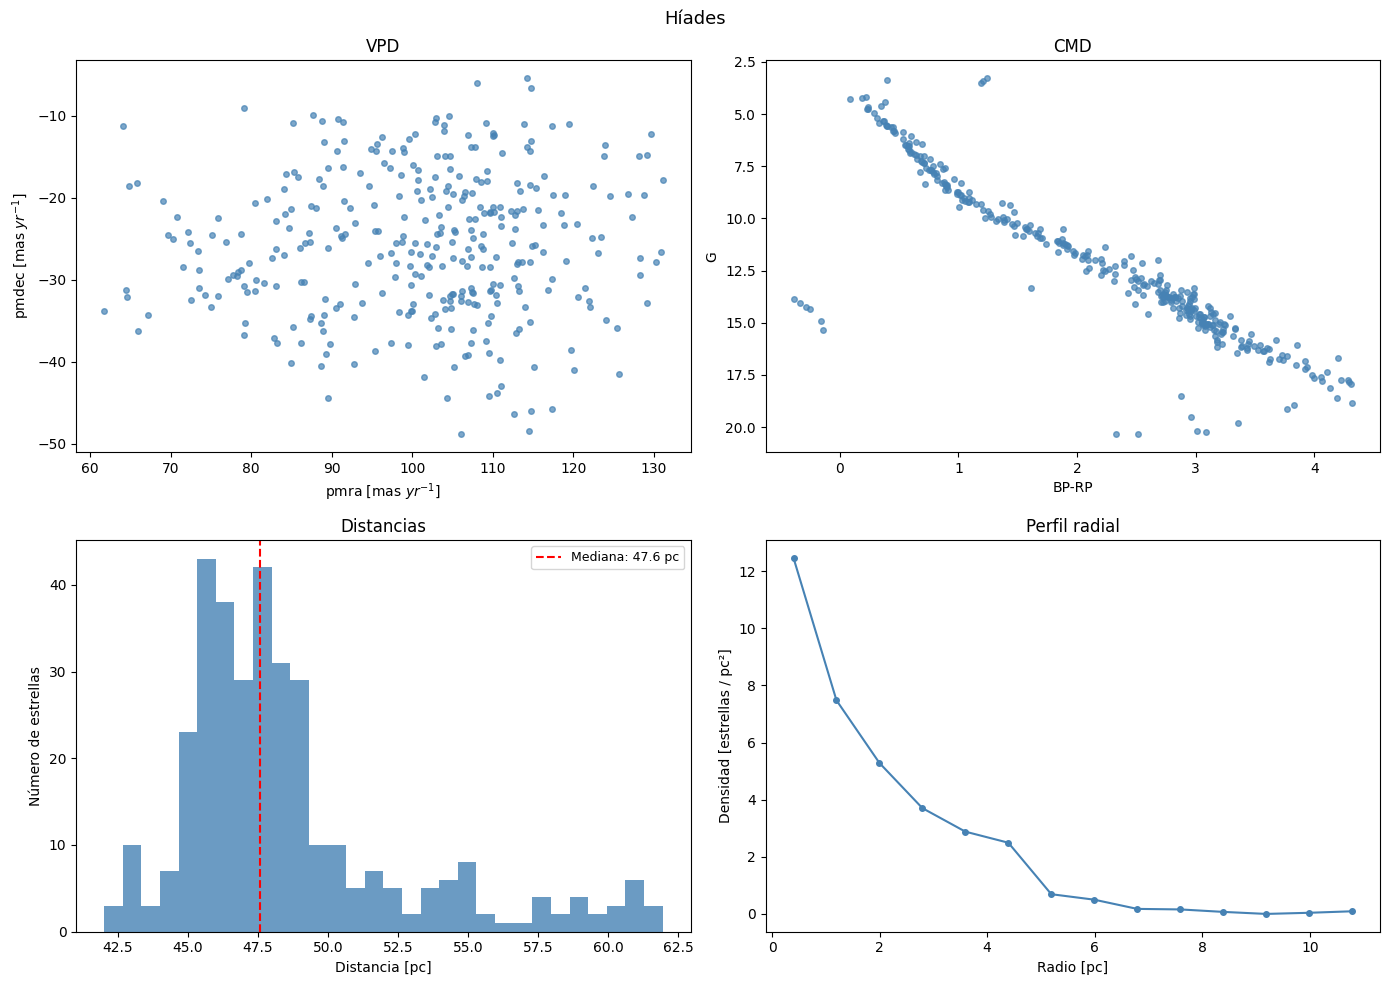

In [57]:
graficar(df_merged, "Híades")